# Pandas Data Wrangling with the Titanic Dataset

This notebook will walk through some common data warngling techniques in pandas with a focus on the groupby and truth indices methods. We perform our analyses on the titanic dataset. 

### dataset description:   
titanic.csv lists all passengers aboard the titanic, provding the following data fields
- Survived: 0 or 1 specifying if they died or survided the accident
- Pclass:  fare class ranging from 3rd to 1st class.
- Name:  Full name of passenger
- Sex:  M/F
- Age: In years with decimal precision
- Siblings/Spouses Aboard: Number of siblings/spouses aboard ship
- Parents/Children Aboard: Number of parents/children aboard ship
- Fare: fare price in dollars

### We will show different techniques to arrive at solutions for the following questions.

- How many people survived?  How many died?
- What was survival rate for males and females??
- How many passengers were in pclass 1, 2, 3?
  groupby(‘Pclass’) or truth indices
- Ratio of Males to Females in Pclass 1, 2, 3?
groupby (‘Pclass’, ‘Sex’) and count
- Generate DataFrame with counts of survived&dead males and females in Pclass 1, 2, and 3.
- What was median age of males and females?
- What was survival rate for people under 18?  over 18?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## read in titanic.csv

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


## How many people survived? How many died?

To find out how many passengers survived or perished, we gain access to the 'Survived' column

In [3]:
df.Survived

# note that df['Survived'] is equivalent syntax for accessing the Survived column

0      0
1      1
2      1
3      1
4      0
      ..
882    0
883    1
884    0
885    1
886    0
Name: Survived, Length: 887, dtype: int64

### Truth indexing is useful for querys
By generating a truth array/truth indices on the Survived column where the logical condition being checked for is equivalence to 1 (meaning survived), we have a direct representation of which rows/passengers Survived or got unlucky.  

In [4]:
# Here we query the survived column values for equivalence to 1. (meaning survived)
df.Survived==1

0      False
1       True
2       True
3       True
4      False
       ...  
882    False
883     True
884    False
885     True
886    False
Name: Survived, Length: 887, dtype: bool

### Use sum() on a truth array to find how many true instances there are.
In this case, the number of true instances corresponds to the number of people who survied.

In [5]:
# find how many people survived by summing truth indices
sum(df.Survived==1)

342

In [6]:
# similarly we find the number of people who died 
sum(df.Survived==0)

545

## What is the mean Fare for each Fare Class?

To answer this question, we introduce the groupby method.

### Using the Groupby method

The groupby method is a way to organize your dataframe in reference to the values of a particular column or set of columns. The method will create groups for each value in the columns(s) specified within groupby. With these groups, we have the freedom to choose how the other columns in the dataframe are aggregated in reference to the group values.


### Aggregation functions

When using groupby in pandas, the common terminology for the columns involved is:

`Grouping columns`: These are called keys or grouping variables. They determine how the data is split into groups. Example: df.groupby("category"), where "category" is the grouping column.

`Aggregating column`s: These are called values, aggregated variables, or target columns. They contain numerical or categorical data that are aggregated using functions like sum(), mean(), count(), etc. Example: df.groupby("category")["temperature"].sum(), where "temperature" is the aggregated column.



In [7]:
# Here we groupby fare class and use the count function on all aggregating columns
# the count function counts the number of instances/rows a column has.
df.groupby('Pclass').count()

,Survived,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
Pclass,,,,,,,
1,216,216,216,216,216,216,216
2,184,184,184,184,184,184,184
3,487,487,487,487,487,487,487


### Side quest: Number of passengers for each Pclass

By applying the count function, we are counting the number of instances a column has for each value in the group. 
  
In the context of the titanic data grouped by Pclass, the count function will give the number of passengers for each Class.

In [8]:
# This shows the number of passengers in each class
df.groupby('Pclass')['Survived'].count()

Pclass
1    216
2    184
3    487
Name: Survived, dtype: int64

In [9]:
# by grouping by fare class and apply the mean function to the fare price aggregate column
# we can find the mean fare price for each fare class
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.707707
Name: Fare, dtype: float64

In [10]:
# note that you can find these values with truth indices isntead of groupby
print(f"Mean fare price for class 1: {df.loc[df.Pclass==1,'Fare'].mean()}")
print(f"Mean fare price for class 2: {df.loc[df.Pclass==2,'Fare'].mean()}")
print(f"Mean fare price for class 3: {df.loc[df.Pclass==3,'Fare'].mean()}")

Mean fare price for class 1: 84.1546875
Mean fare price for class 2: 20.662183152173913
Mean fare price for class 3: 13.707707392197124


## Survival Rates for Males and Females

Continuing with the surival column, we now investigate the surival rates for both men and women. 

Groupby is also useful in this context because we can divide our data into survived/died for both males and femals separately.

This is achieved by specifying both Sex and Survived columns as our grouping columns and count for our aggregation function. 


In [11]:
# Find total number of survived/died for both males/females
df.groupby(['Sex', 'Survived']).count()

Pclass  Name  Age  Siblings/Spouses Aboard  \
Sex    Survived                                               
female 0             81    81   81                       81   
       1            233   233  233                      233   
male   0            464   464  464                      464   
       1            109   109  109                      109   

                 Parents/Children Aboard  Fare  
Sex    Survived                                 
female 0                              81    81  
       1                             233   233  
male   0                             464   464  
       1                             109   109

In [12]:
# We can extract one aggregate column to get the counts into a series
# Pclass is a random choice, and could have been any other column
df.groupby(['Sex', 'Survived'])['Pclass'].count()

Sex     Survived
female  0            81
        1           233
male    0           464
        1           109
Name: Pclass, dtype: int64

In [13]:
# Removing 'Survived' from our groupby, we can get total number of females and males.
df.groupby('Sex')['Pclass'].count()

Sex
female    314
male      573
Name: Pclass, dtype: int64

In [14]:
# By dividing these two series, we can find the proportion survived for both m/f.

In [15]:
ratios = df.groupby(['Sex', 'Survived'])['Pclass'].count() / df.groupby('Sex')['Pclass'].count()
ratios

Sex     Survived
female  0           0.257962
        1           0.742038
male    0           0.809773
        1           0.190227
Name: Pclass, dtype: float64

In [16]:
# Using .loc to index, we can specify both sexes and survived values of 1
# to get the proportion of females and males that survived.
ratios.loc[:,1]

Sex
female    0.742038
male      0.190227
Name: Pclass, dtype: float64

### Equivalent solution using truth indices

In [17]:
# number of survived females / total number of females
sum((df.Survived==1) & (df.Sex=='female')) / sum(df.Sex=='female')

0.7420382165605095

In [18]:
# number of survived males / total number of males
sum((df.Survived==1) & (df.Sex=='male')) / sum(df.Sex=='male')

0.19022687609075042

## Finding survival rates by Class and Sex.

Continuing with the survival rates question, we can further break down survival rates by male/female by introducing class as one of our groups.
  
"What are the survival rates for males/females in 1st class, 2nd class, and 3rd class?"


In [19]:
# first we get counts of males/females in each class
mf_counts_class = df.groupby(['Pclass','Sex'])['Pclass'].count()
mf_counts_class

Pclass  Sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      343
Name: Pclass, dtype: int64

In [20]:
# then we get counts of survived/died, males/females in each class
smf_counts_class = df.groupby(['Pclass','Sex', 'Survived'])['Pclass'].count() 
smf_counts_class


Pclass  Sex     Survived
1       female  0             3
                1            91
        male    0            77
                1            45
2       female  0             6
                1            70
        male    0            91
                1            17
3       female  0            72
                1            72
        male    0           296
                1            47
Name: Pclass, dtype: int64

In [21]:
# dividing the surival counts by the total counts, we get survival proportions for each category
class_sex_survival_rates = smf_counts_class/mf_counts_class
class_sex_survival_rates

Pclass  Sex     Survived
1       female  0           0.031915
                1           0.968085
        male    0           0.631148
                1           0.368852
2       female  0           0.078947
                1           0.921053
        male    0           0.842593
                1           0.157407
3       female  0           0.500000
                1           0.500000
        male    0           0.862974
                1           0.137026
Name: Pclass, dtype: float64

In [62]:
# we can now index our survival rates series to get only survied passengers
# loc[class, sex, survived]
class_sex_lived_percent = class_sex_survival_rates.loc[:,:,1] *100 # convert to percentage
class_sex_lived_percent

Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.702624
Name: Pclass, dtype: float64

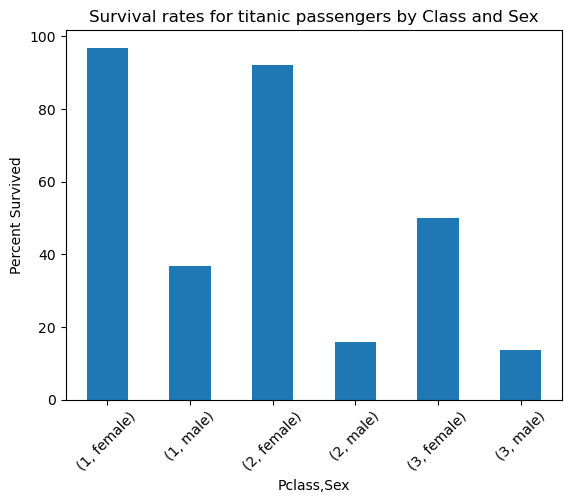

In [63]:
# visualizing survival percentages based on our groups
_ = class_sex_lived_rates.plot(kind='bar')
_ = plt.xticks(rotation=45)
_ = plt.title('Survival rates for titanic passengers by Class and Sex')
_ = plt.ylabel('Percent Survived')



## What are the ratios of males to females by class?

"for every man how many women were there?"

In [81]:
# Here we get the total counts of males and females broken down by class
num_mf_by_class = df.groupby(['Pclass','Sex'])['Pclass'].count()
num_mf_by_class

Pclass  Sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      343
Name: Pclass, dtype: int64

In [82]:
# Here we get the ratios of males to females broken down by class

# num of males in each class / num of females in each class
num_mf_by_class.loc[:,'male']/ num_mf_by_class.loc[:,'female']

Pclass
1    1.297872
2    1.421053
3    2.381944
Name: Pclass, dtype: float64